In [ ]:
from google.colab import files
uploaded = files.upload()

Saving annotation_results.xlsx to annotation_results.xlsx


In [ ]:
import os
os.remove("results_vote_studychat.json")

In [ ]:
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
# @title
import json
import pandas as pd
from datasets import load_dataset

# --- le corpus ---
ds = load_dataset("wmcnicho/StudyChat")
df_sc = ds['train'].to_pandas()
df_sc = df_sc.rename(columns={
    'chatId': 'Id',
    'interactionCount': 'Turn_id',
    'prompt': 'User',
    'response': 'Assistant',
})
df_sc = df_sc.sort_values(['Id', 'Turn_id'])

# --- les votes ---
with open("results_vote_studychat.json", encoding="utf-8") as f:
    all_results = json.load(f)

rows = []
for student_id, turns in all_results.items():
    for turn_id, values in turns.items():
        rows.append({
            'Id': student_id,
            'Turn_id': int(turn_id),
            'emotion_user': values.get('emotion_vote'),
        })
df_emotions = pd.DataFrame(rows)
df_emotions['Id'] = df_emotions['Id'].astype(df_sc['Id'].dtype)

df_sc = df_sc.merge(df_emotions, on=['Id', 'Turn_id'], how='left')

print(f"{len(df_sc)} tours, {df_sc['emotion_user'].isna().sum()} sans annotation")
print(df_sc['emotion_user'].value_counts(dropna=False))

16851 tours, 0 sans annotation
emotion_user
engagement     7960
confusion      3104
neutral        2950
curiosity      1926
frustration     902
boredom           9
Name: count, dtype: int64


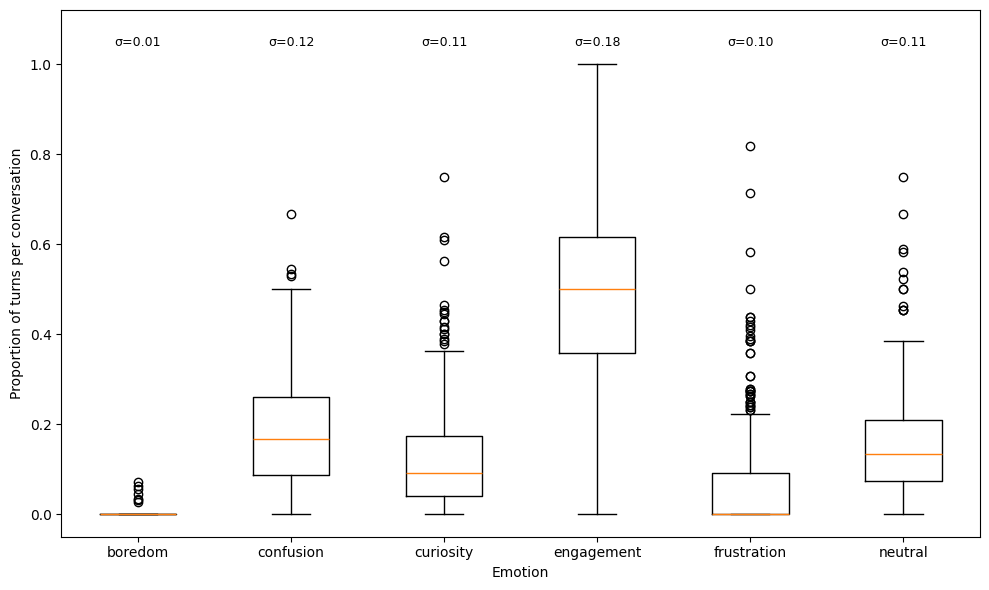

508 conversations (> 10 tours), 10860 tours


In [ ]:
# @title
import matplotlib.pyplot as plt

MIN_TURNS = 10

# garder les conversations de plus de 10 tours
sizes = df_emotions.groupby('Id').size()
long_ids = sizes[sizes > MIN_TURNS].index
df_long = df_emotions[df_emotions['Id'].isin(long_ids)]

proportions = df_long.groupby(['Id', 'emotion_user']).size().unstack(fill_value=0)
proportions = proportions.div(proportions.sum(axis=1), axis=0)

emotions = list(proportions.columns)
fig, ax = plt.subplots(figsize=(10, 6))

ax.boxplot([proportions[e] for e in emotions], tick_labels=emotions)

y_max = proportions[emotions].max().max()
for i, e in enumerate(emotions):
    ax.text(i + 1, y_max + 0.04, f'σ={proportions[e].std():.2f}',
            ha='center', fontsize=9)

ax.set_ylim(top=y_max + 0.12)
ax.set_ylabel("Proportion of turns per conversation")
ax.set_xlabel("Emotion")
plt.tight_layout()
plt.show()

print(f"{len(long_ids)} conversations (> {MIN_TURNS} tours), {len(df_long)} tours")

#Actions


In [ ]:

import matplotlib.pyplot as plt
import pandas as pd

df_turns = pd.read_csv("/content/df_turns.csv")
df_conversations = pd.read_csv("/content/df_conversations.csv")

ALIAS = {"curiosite": "curiosity"}

with open("results_vote.json", "r", encoding="utf-8") as f:
    all_results = json.load(f)

rows = []
for student_id, turns in all_results.items():
    for turn_id, values in turns.items():
        emo = values.get('emotion_vote')
        rows.append({
            'Id': int(student_id),
            'Turn_id': int(turn_id),
            'emotion_user': ALIAS.get(emo, emo),
        })
df_emotions_hack = pd.DataFrame(rows)

df_turns = df_turns.merge(
    df_emotions_hack[['Id', 'Turn_id', 'emotion_user']],
    on=['Id', 'Turn_id'],
    how='left',
)

print(f"{df_emotions_hack['Id'].nunique()} conversations, {len(df_emotions_hack)} tours")
print(df_turns['emotion_user'].value_counts())

73 conversations, 1825 tours
emotion_user
engagement     809
confusion      371
neutral        298
frustration    266
curiosity       63
boredom         18
Name: count, dtype: int64


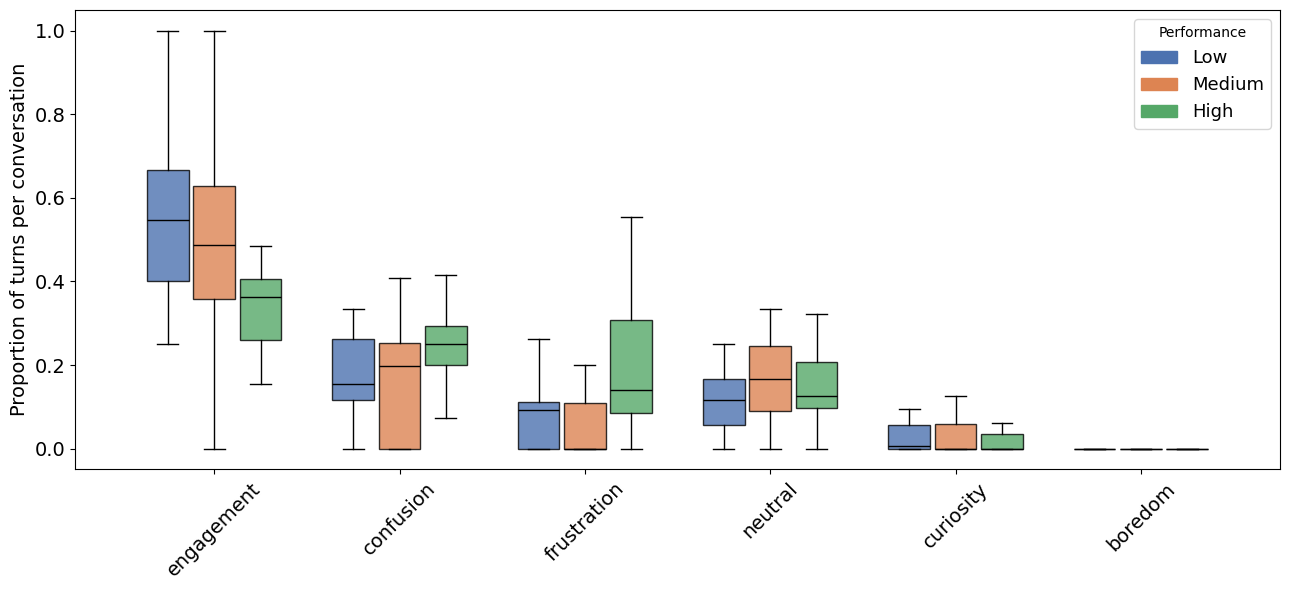

In [ ]:
# @title
import numpy as np
import matplotlib.patches as mpatches

emo_prop = (
    df_turns.groupby('Id')['emotion_user']
    .value_counts(normalize=True)
    .unstack(fill_value=0.0)
    .reset_index()
)
df_conversations = df_conversations.merge(emo_prop, on='Id', how='left')
df_conversations['niveau'] = pd.qcut(df_conversations['grade'], q=[0, .25, .75, 1.], labels=['Low','Medium','High'])

emotions = ['engagement', 'confusion', 'frustration', 'neutral', 'curiosity', 'boredom']
emotions = [e for e in emotions if e in df_conversations.columns]
niveaux = ['Low', 'Medium', 'High']
couleurs = {'Low': '#4c72b0', 'Medium': '#dd8452', 'High': '#55a868'}

fig, ax = plt.subplots(figsize=(13, 6))
width = 0.25

for j, niveau in enumerate(niveaux):
    df_niv = df_conversations[df_conversations['niveau'] == niveau]
    positions = np.arange(len(emotions)) + (j - 1) * width
    data = [df_niv[e].dropna().values for e in emotions]
    bp = ax.boxplot(
        data,
        positions=positions,
        widths=width * 0.9,
        patch_artist=True,
        medianprops=dict(color='black'),
        showfliers=False,
    )
    for box in bp['boxes']:
        box.set_facecolor(couleurs[niveau])
        box.set_alpha(0.8)
ax.set_xticks(np.arange(len(emotions)))
ax.set_xticklabels(emotions, rotation=45, fontsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.set_ylabel('Proportion of turns per conversation', fontsize=14)

legend = [mpatches.Patch(color=couleurs[n], label=n) for n in niveaux]
ax.legend(handles=legend, fontsize=13, title='Performance')

plt.tight_layout()
plt.show()

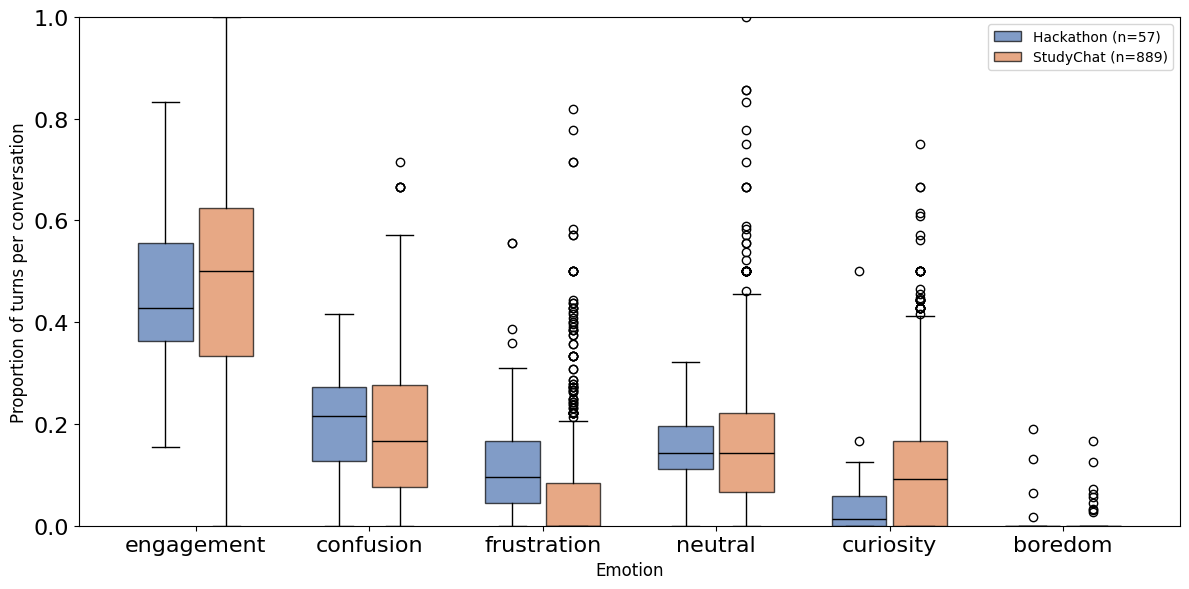

Hackathon : 57 convs (> 5 tours)
StudyChat : 889 convs (> 5 tours)


In [ ]:
# @title
import matplotlib.pyplot as plt
import numpy as np

MIN_TURNS = 5
EMOTIONS = ['engagement', 'confusion', 'frustration', 'neutral', 'curiosity', 'boredom']


def proportions_par_conv(df, col='emotion_user'):
    d = df[df[col].notna()]
    sizes = d.groupby('Id').size()
    long_ids = sizes[sizes > MIN_TURNS].index
    d = d[d['Id'].isin(long_ids)]
    p = d.groupby(['Id', col]).size().unstack(fill_value=0)
    p = p.div(p.sum(axis=1), axis=0)
    return p.reindex(columns=EMOTIONS, fill_value=0), len(long_ids)


p_hack, n_hack = proportions_par_conv(df_emotions_hack)
p_sc,   n_sc   = proportions_par_conv(df_sc)

fig, ax = plt.subplots(figsize=(12, 6))
width = 0.35
x = np.arange(len(EMOTIONS))

b1 = ax.boxplot([p_hack[e] for e in EMOTIONS], positions=x - width/2,
                widths=width*0.9, patch_artist=True,
                boxprops=dict(facecolor='#4C72B0', alpha=.7),
                medianprops=dict(color='black'))
b2 = ax.boxplot([p_sc[e] for e in EMOTIONS], positions=x + width/2,
                widths=width*0.9, patch_artist=True,
                boxprops=dict(facecolor='#DD8452', alpha=.7),
                medianprops=dict(color='black'))

ax.set_xticks(x)
ax.set_xticklabels(EMOTIONS, fontsize=16)
ax.set_ylabel("Proportion of turns per conversation",fontsize=12)
ax.set_xlabel("Emotion",fontsize=12)
ax.tick_params(axis='y', labelsize=16)
ax.legend([b1["boxes"][0], b2["boxes"][0]],
          [f"Hackathon (n={n_hack})", f"StudyChat (n={n_sc})"])
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

print(f"Hackathon : {n_hack} convs (> {MIN_TURNS} tours)")
print(f"StudyChat : {n_sc} convs (> {MIN_TURNS} tours)")

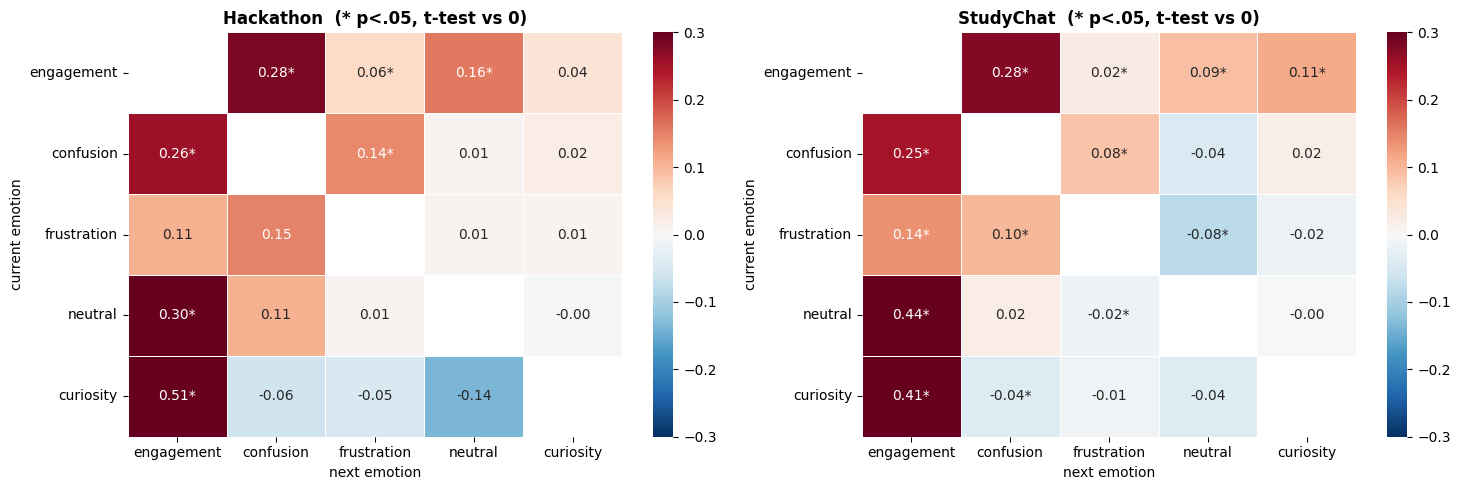

In [ ]:
# @title
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

ORDRE = ['engagement', 'confusion', 'frustration', 'neutral', 'curiosity']


def L_par_sujet(df, emo_col, seg_col, subj_col):
    """Retourne un dict {(src, dst): [L par sujet]}.
    - transitions comptées SANS franchir une frontière de segment (seg_col)
    - répétitions consécutives supprimées dans chaque segment (recodage Dynamics)
    - base rate P(dst) calculé sur la SÉQUENCE RECODÉE (fréquence des états visités),
      pas sur les comptes de transitions
    - L calculé par sujet (subj_col), en poolant ses segments
    """
    d = df[df[emo_col].notna()].copy()
    Ls = {(s, t): [] for s in ORDRE for t in ORDRE if s != t}

    for subj, g_subj in d.groupby(subj_col):
        cnt = pd.DataFrame(0, index=ORDRE, columns=ORDRE, dtype=float)  # transitions
        state_count = pd.Series(0.0, index=ORDRE)                       # occurrences d'états (recodé)

        for _, g_seg in g_subj.groupby(seg_col):
            seq = g_seg.sort_values('Turn_id')[emo_col].tolist()
            # recodage : suppression des répétitions consécutives
            seq = [e for i, e in enumerate(seq) if i == 0 or e != seq[i - 1]]
            # comptage des états visités (pour le base rate)
            for e in seq:
                if e in ORDRE:
                    state_count[e] += 1
            # comptage des transitions
            for a, b in zip(seq, seq[1:]):
                if a in ORDRE and b in ORDRE:
                    cnt.loc[a, b] += 1

        if cnt.values.sum() == 0:
            continue

        # base rate = fréquence de l'état dans la séquence recodée
        base = state_count / state_count.sum()
        row_tot = cnt.sum(axis=1)               # nb transitions depuis chaque src

        for s in ORDRE:
            if row_tot[s] == 0:
                continue                         # sujet n'a jamais quitté cet état -> L indéfini
            for t in ORDRE:
                if s == t:
                    continue
                cond = cnt.loc[s, t] / row_tot[s]    # P(dst|src)
                p = base[t]
                if p < 1:
                    Ls[(s, t)].append((cond - p) / (1 - p))
    return Ls


def matrice_et_signif(Ls):
    M = pd.DataFrame(np.nan, index=ORDRE, columns=ORDRE)
    P = pd.DataFrame(np.nan, index=ORDRE, columns=ORDRE)
    N = pd.DataFrame(0, index=ORDRE, columns=ORDRE)
    for (s, t), vals in Ls.items():
        vals = [v for v in vals if not np.isnan(v)]
        N.loc[s, t] = len(vals)
        if len(vals) >= 2:
            M.loc[s, t] = np.mean(vals)
            P.loc[s, t] = stats.ttest_1samp(vals, 0.0).pvalue
    return M, P, N


# Hackathon : segment = Id, sujet = Id
Ls_h = L_par_sujet(df_turns, 'emotion_user', seg_col='Id', subj_col='Id')
M_h, P_h, N_h = matrice_et_signif(Ls_h)

# StudyChat : segment = Id (conversation), sujet = userId (étudiant)
Ls_s = L_par_sujet(df_sc, 'emotion_user', seg_col='Id', subj_col='userId')
M_s, P_s, N_s = matrice_et_signif(Ls_s)


def annot_matrix(M, P):
    out = pd.DataFrame('', index=ORDRE, columns=ORDRE)
    for s in ORDRE:
        for t in ORDRE:
            v = M.loc[s, t]
            if pd.isna(v):
                out.loc[s, t] = ''
            else:
                star = '*' if (pd.notna(P.loc[s, t]) and P.loc[s, t] < 0.05) else ''
                out.loc[s, t] = f"{v:.2f}{star}"
    return out


fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, M, P, N, titre in [
    (axes[0], M_h, P_h, N_h, "Hackathon"),
    (axes[1], M_s, P_s, N_s, "StudyChat"),
]:
    annot = annot_matrix(M, P)
    ylabels = ORDRE
    sns.heatmap(M.astype(float), annot=annot, fmt='', cmap='RdBu_r', center=0,
                vmin=-0.3, vmax=0.3, yticklabels=ylabels, xticklabels=ORDRE,
                ax=ax, cbar=True, linewidths=.5, linecolor='white')
    ax.set_title(f"{titre}  (* p<.05, t-test vs 0)", fontweight='bold')
    ax.set_xlabel("next emotion")
    ax.set_ylabel("current emotion")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats

ORDRE = ['engagement', 'confusion', 'frustration', 'neutral', 'curiosity']


def L_autotransitions(df, emo_col, seg_col, subj_col):
    """L d'auto-transition (persistance) par état, calculé par sujet.
    Séquences NON recodées (on garde les répétitions pour mesurer la persistance).
    """
    d = df[df[emo_col].notna()].copy()
    Ls = {e: [] for e in ORDRE}

    for subj, g_subj in d.groupby(subj_col):
        cnt = pd.DataFrame(0, index=ORDRE, columns=ORDRE, dtype=float)
        state_count = pd.Series(0.0, index=ORDRE)

        for _, g_seg in g_subj.groupby(seg_col):
            seq = g_seg.sort_values('Turn_id')[emo_col].tolist()
            # PAS de recodage : on garde les répétitions
            for e in seq:
                if e in ORDRE:
                    state_count[e] += 1
            for a, b in zip(seq, seq[1:]):
                if a in ORDRE and b in ORDRE:
                    cnt.loc[a, b] += 1

        if cnt.values.sum() == 0:
            continue
        base = state_count / state_count.sum()      # P(dst) sur séquence brute
        row_tot = cnt.sum(axis=1)

        for e in ORDRE:
            if row_tot[e] == 0:
                continue
            cond = cnt.loc[e, e] / row_tot[e]        # P(rester dans e | on est en e)
            p = base[e]
            if p < 1:
                Ls[e].append((cond - p) / (1 - p))
    return Ls


def tableau_persistance(Ls, nom):
    print(f"\n=== Persistance (auto-transitions) — {nom} ===")
    print(f"{'état':<14}{'L moyen':>10}{'SD':>8}{'N':>6}{'t':>8}{'p':>9}")
    for e in ORDRE:
        vals = [v for v in Ls[e] if not np.isnan(v)]
        if len(vals) >= 2:
            m, sd = np.mean(vals), np.std(vals, ddof=1)
            t, p = stats.ttest_1samp(vals, 0.0)
            sig = '*' if p < 0.05 else ''
            print(f"{e:<14}{m:>10.3f}{sd:>8.3f}{len(vals):>6}{t:>8.2f}{p:>9.4f} {sig}")
        else:
            print(f"{e:<14}{'—':>10}{'':>8}{len(vals):>6}")


# Hackathon : segment = Id, sujet = Id
Ls_h = L_autotransitions(df_turns, 'emotion_user', seg_col='Id', subj_col='Id')
tableau_persistance(Ls_h, "Hackathon")

# StudyChat : segment = Id (conversation), sujet = userId (étudiant)
Ls_s = L_autotransitions(df_sc, 'emotion_user', seg_col='Id', subj_col='userId')
tableau_persistance(Ls_s, "StudyChat")


=== Persistance (auto-transitions) — Hackathon ===
état             L moyen      SD     N       t        p
engagement         0.014   0.293    60    0.37   0.7137 
confusion          0.009   0.277    56    0.25   0.8015 
frustration        0.106   0.242    40    2.78   0.0082 *
neutral           -0.066   0.268    56   -1.85   0.0700 
curiosity         -0.010   0.237    15   -0.16   0.8730 

=== Persistance (auto-transitions) — StudyChat ===
état             L moyen      SD     N       t        p
engagement         0.132   0.390   194    4.70   0.0000 *
confusion          0.136   0.195   169    9.08   0.0000 *
frustration        0.222   0.266   107    8.62   0.0000 *
neutral           -0.001   0.288   191   -0.04   0.9679 
curiosity          0.041   0.193   167    2.78   0.0061 *


0 tours sans action
broad_user
writing                 480
provide_context         449
contextual_questions    356
conceptual_questions    238
editing                 138
verification            137
off_topic                26
misc                      1
Name: count, dtype: int64


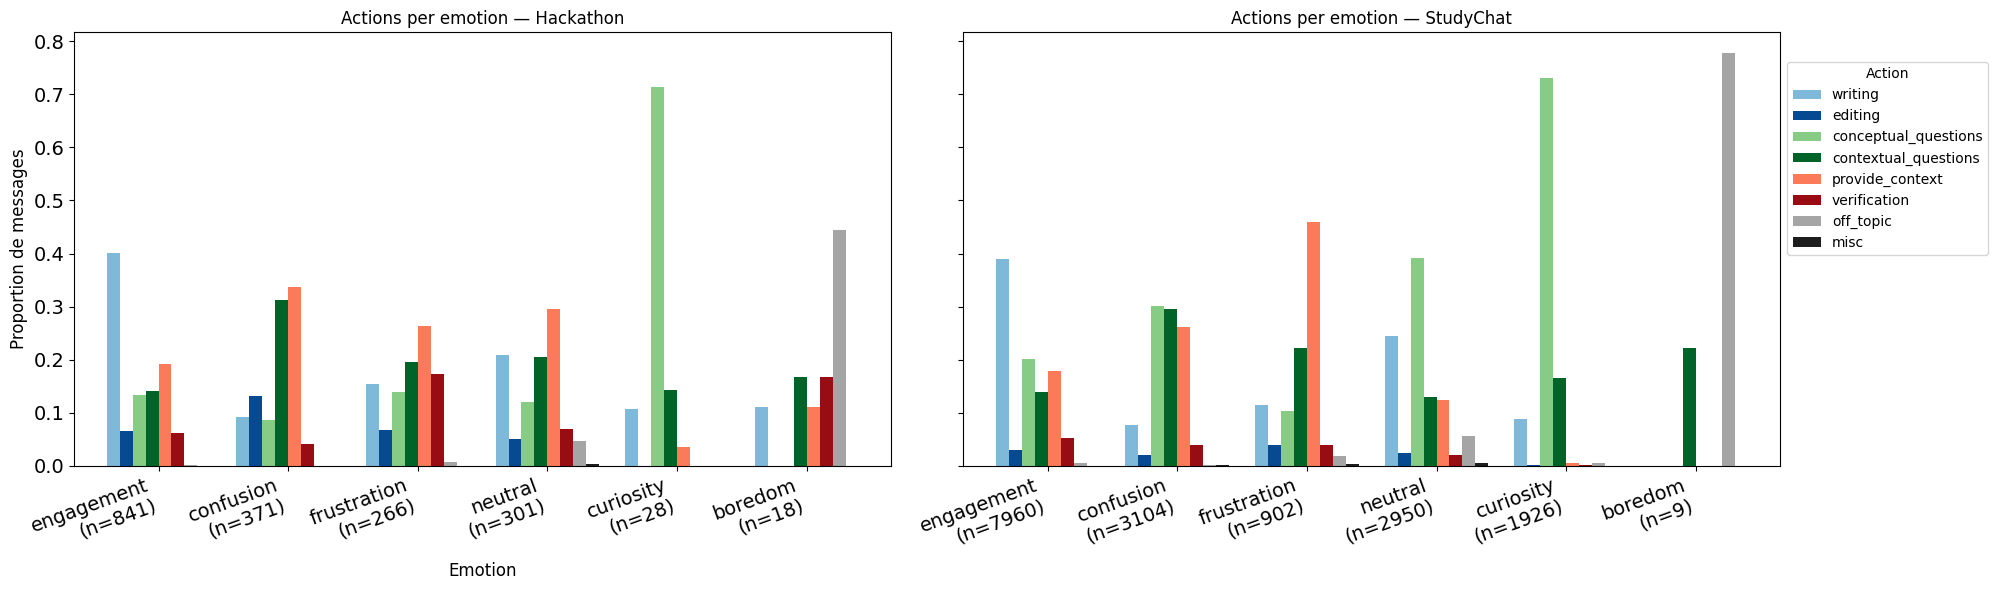

=== Hackathon ===
emotion_user          engagement  confusion  frustration  neutral  curiosity  \
broad_user                                                                     
writing                    0.401      0.092        0.154    0.209      0.107   
editing                    0.067      0.132        0.068    0.050      0.000   
conceptual_questions       0.134      0.086        0.139    0.120      0.714   
contextual_questions       0.141      0.313        0.195    0.206      0.143   
provide_context            0.193      0.337        0.263    0.296      0.036   
verification               0.062      0.040        0.173    0.070      0.000   
off_topic                  0.002      0.000        0.008    0.047      0.000   
misc                       0.000      0.000        0.000    0.003      0.000   

emotion_user          boredom  
broad_user                     
writing                 0.111  
editing                 0.000  
conceptual_questions    0.000  
contextual_questions 

In [ ]:
# @title
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd
import json

with open("actions_vote.json", encoding="utf-8") as f:
    res_act = json.load(f)

rows = [{'Id': int(sid), 'Turn_id': int(tid),
         'action_user': v.get('action_vote'),
         'broad_user': v.get('broad_vote')}
        for sid, turns in res_act.items() for tid, v in turns.items()]

df_actions = pd.DataFrame(rows)
df_turns = df_turns.merge(df_actions, on=['Id', 'Turn_id'], how='left')

print(df_turns['broad_user'].isna().sum(), "tours sans action")
print(df_turns['broad_user'].value_counts())

ACTIONS = [
    'writing', 'editing',
    'conceptual_questions', 'contextual_questions',
    'provide_context', 'verification',
    'off_topic', 'misc',
]
EMOTIONS = ['engagement', 'confusion', 'frustration', 'neutral', 'curiosity', 'boredom']

# --- parser les labels StudyChat si pas déjà fait ---
def get_broad(val):
    try:
        obj = json.loads(val) if isinstance(val, str) else val
        b = obj.get('label', '').split('>')[0].strip().lower().replace(' ', '_')
        return {'writing_request': 'writing', 'editing_request': 'editing'}.get(b, b)
    except Exception:
        return None

if 'broad_sc' not in df_sc.columns:
    df_sc['broad_sc'] = df_sc['llm_label'].apply(get_broad)


def table_croisee(df, act_col, emo_col='emotion_user'):
    sub = df[df[act_col].notna() & df[emo_col].isin(EMOTIONS)]
    tbl = pd.crosstab(sub[act_col], sub[emo_col], normalize='columns')
    tbl = tbl.reindex(index=ACTIONS, columns=EMOTIONS, fill_value=0)
    n = sub[emo_col].value_counts()
    return tbl, n


# Bleus pour writing/editing, verts pour les questions, rouges pour context/verification, gris pour le reste
def palette_categorie():
    familles = {
        'writing': cm.Blues, 'editing': cm.Blues,
        'conceptual_questions': cm.Greens, 'contextual_questions': cm.Greens,
        'provide_context': cm.Reds, 'verification': cm.Reds,
        'off_topic': cm.Greys, 'misc': cm.Greys,
    }
    groupes = {}
    for a in ACTIONS:
        groupes.setdefault(familles[a].name, []).append(a)
    couleurs = []
    for a in ACTIONS:
        g = groupes[familles[a].name]
        t = 0.45 + 0.45 * (g.index(a) / max(len(g) - 1, 1))
        couleurs.append(familles[a](t))
    return couleurs


COULEURS = palette_categorie()

tbl_hack, n_hack = table_croisee(df_turns, 'broad_user')
tbl_sc,   n_sc   = table_croisee(df_sc,    'broad_sc')

fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharey=True)

for ax, tbl, n, titre in [(axes[0], tbl_hack, n_hack, "Hackathon"),
                          (axes[1], tbl_sc,   n_sc,   "StudyChat")]:
    tbl.T.plot(kind='bar', ax=ax, width=0.8, color=COULEURS, legend=False)
    ax.set_title(f"Actions per emotion — {titre}", fontsize=12)
    ax.set_xlabel("")
    ax.set_xticklabels([f"{e}\n(n={n.get(e, 0)})" for e in EMOTIONS],
                       rotation=20, ha='right', fontsize=14)
    ax.tick_params(axis='y', labelsize=14)

axes[0].set_ylabel("Proportion de messages", fontsize=12)
axes[0].set_xlabel("Emotion", fontsize=12)
h, l = axes[0].get_legend_handles_labels()
fig.legend(h, l, title="Action", bbox_to_anchor=(1.0, 0.9))
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

print("=== Hackathon ==="); print(tbl_hack.round(3))
print("\n=== StudyChat ==="); print(tbl_sc.round(3))


Kappa - Annotation

In [ ]:
# @title
import pandas as pd
import json
import unicodedata
from sklearn.metrics import cohen_kappa_score, classification_report

# ---- Normalisation (même logique que merge.py) ----
ALIAS = {
    "curiosite": "curiosity", "curiosity": "curiosity",
    "ennui": "boredom", "boredom": "boredom",
    "neutre": "neutral", "neutral": "neutral",
    "engagement": "engagement", "confusion": "confusion",
    "frustration": "frustration",
}
def normaliser(label):
    if not isinstance(label, str) or not label.strip():
        return None
    label = label.lower().strip()
    label = unicodedata.normalize('NFKD', label)
    label = ''.join(c for c in label if not unicodedata.combining(c))
    return ALIAS.get(label, label)

# ---- Annotation humaine ----
df_h = pd.read_excel('annotation_results.xlsx')
df_h['human'] = df_h['Annotation'].apply(normaliser)

# ---- Vote LLM (n=16 corrigé) ----
with open('results_vote.json', encoding='utf-8') as f:
    vote = json.load(f)

rows = []
for sid, turns in vote.items():
    for tid, obj in turns.items():
        rows.append({'Id': int(sid), 'Turn_id': int(tid),
                     'llm': normaliser(obj.get('emotion_vote'))})
df_v = pd.DataFrame(rows)

# ---- Alignement sur (Id, Turn_id) ----
df = df_h[['Id', 'Turn_id', 'human']].merge(df_v, on=['Id', 'Turn_id'], how='inner')
df = df.dropna(subset=['human', 'llm'])

print(f"{len(df)} tours comparés")
print("\nLabels humains:", df['human'].value_counts().to_dict())
print("Labels LLM:", df['llm'].value_counts().to_dict())

# ---- Cohen's kappa ----
kappa = cohen_kappa_score(df['human'], df['llm'])
print(f"\nCohen's kappa = {kappa:.3f}")

# ---- Précision / rappel / F1 par émotion ----
print("\n" + classification_report(df['human'], df['llm'], zero_division=0))

180 tours comparés

Labels humains: {'engagement': 139, 'confusion': 29, 'frustration': 12}
Labels LLM: {'engagement': 71, 'confusion': 53, 'frustration': 38, 'neutral': 17, 'curiosity': 1}

Cohen's kappa = 0.194

              precision    recall  f1-score   support

   confusion       0.30      0.55      0.39        29
   curiosity       0.00      0.00      0.00         0
  engagement       0.92      0.47      0.62       139
 frustration       0.18      0.58      0.28        12
     neutral       0.00      0.00      0.00         0

    accuracy                           0.49       180
   macro avg       0.28      0.32      0.26       180
weighted avg       0.77      0.49      0.56       180



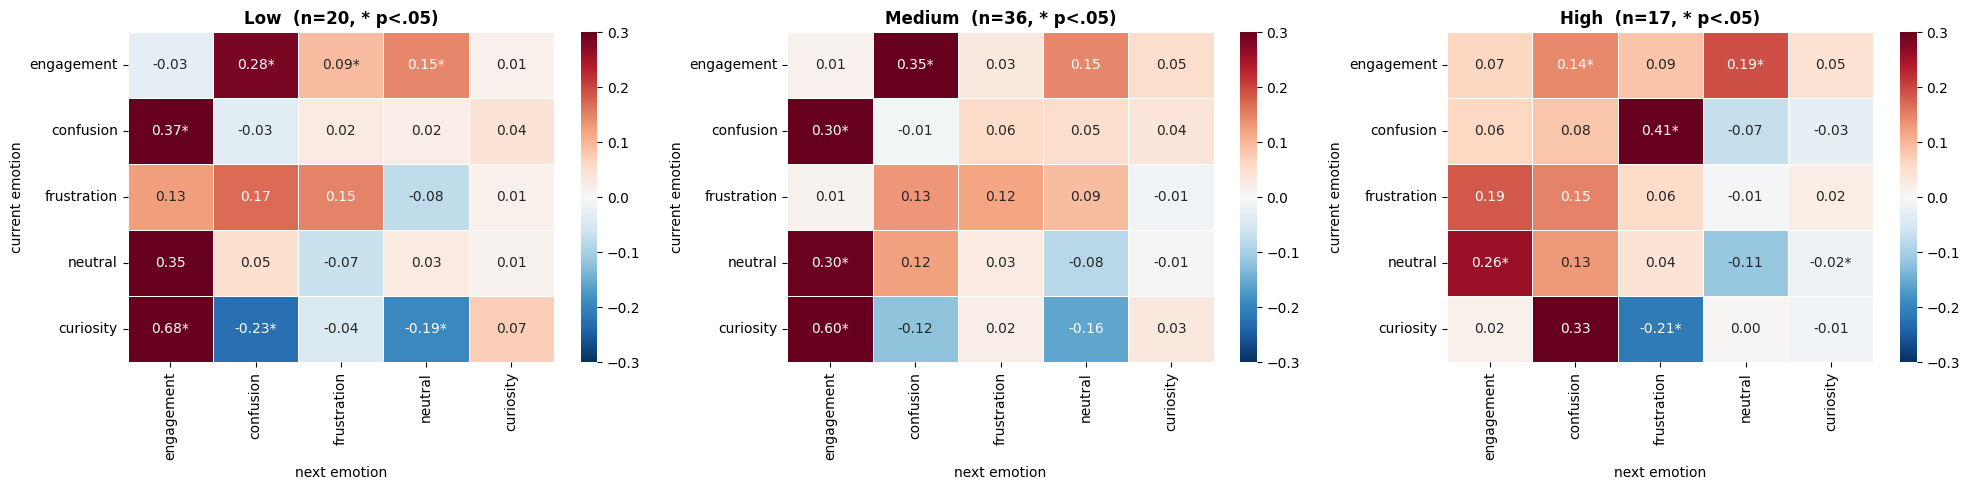

In [ ]:
# @title Heatmap par niveau : diag = persistance, hors-diag = transitions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

ORDRE = ['engagement', 'confusion', 'frustration', 'neutral', 'curiosity']


def L_par_sujet(df, emo_col, seg_col, subj_col, recode):
    d = df[df[emo_col].notna()].copy()
    Ls = {(s, t): [] for s in ORDRE for t in ORDRE}
    for subj, g_subj in d.groupby(subj_col):
        cnt = pd.DataFrame(0, index=ORDRE, columns=ORDRE, dtype=float)
        state_count = pd.Series(0.0, index=ORDRE)
        for _, g_seg in g_subj.groupby(seg_col):
            seq = g_seg.sort_values('Turn_id')[emo_col].tolist()
            if recode:
                seq = [e for i, e in enumerate(seq) if i == 0 or e != seq[i - 1]]
            for e in seq:
                if e in ORDRE:
                    state_count[e] += 1
            for a, b in zip(seq, seq[1:]):
                if a in ORDRE and b in ORDRE:
                    cnt.loc[a, b] += 1
        if cnt.values.sum() == 0:
            continue
        base = state_count / state_count.sum()
        row_tot = cnt.sum(axis=1)
        for s in ORDRE:
            if row_tot[s] == 0:
                continue
            for t in ORDRE:
                cond = cnt.loc[s, t] / row_tot[s]
                p = base[t]
                if p < 1:
                    Ls[(s, t)].append((cond - p) / (1 - p))
    return Ls


def matrice_et_signif(Ls):
    M = pd.DataFrame(np.nan, index=ORDRE, columns=ORDRE)
    P = pd.DataFrame(np.nan, index=ORDRE, columns=ORDRE)
    for (s, t), vals in Ls.items():
        vals = [v for v in vals if not np.isnan(v)]
        if len(vals) >= 2:
            M.loc[s, t] = np.mean(vals)
            P.loc[s, t] = stats.ttest_1samp(vals, 0.0).pvalue
    return M, P


def combiner(df, emo_col, seg_col, subj_col):
    M_off, P_off = matrice_et_signif(L_par_sujet(df, emo_col, seg_col, subj_col, recode=True))
    M_diag, P_diag = matrice_et_signif(L_par_sujet(df, emo_col, seg_col, subj_col, recode=False))
    M = M_off.copy()
    P = P_off.copy()
    for s in ORDRE:
        M.loc[s, s] = M_diag.loc[s, s]
        P.loc[s, s] = P_diag.loc[s, s]
    return M, P


def annot_matrix(M, P):
    out = pd.DataFrame('', index=ORDRE, columns=ORDRE)
    for s in ORDRE:
        for t in ORDRE:
            v = M.loc[s, t]
            if pd.isna(v):
                out.loc[s, t] = ''
            else:
                star = '*' if (pd.notna(P.loc[s, t]) and P.loc[s, t] < 0.05) else ''
                out.loc[s, t] = f"{v:.2f}{star}"
    return out


# rattacher le niveau à chaque tour
niveau_par_id = df_conversations.set_index('Id')['niveau'].to_dict()
df_turns['niveau'] = df_turns['Id'].map(niveau_par_id)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, niveau in zip(axes, ['Low', 'Medium', 'High']):
    df_niv = df_turns[df_turns['niveau'] == niveau]
    M, P = combiner(df_niv, 'emotion_user', 'Id', 'Id')
    annot = annot_matrix(M, P)
    n_students = df_niv['Id'].nunique()
    sns.heatmap(M.astype(float), annot=annot, fmt='', cmap='RdBu_r', center=0,
                vmin=-0.3, vmax=0.3, yticklabels=ORDRE, xticklabels=ORDRE,
                ax=ax, cbar=True, linewidths=.5, linecolor='white')
    ax.set_title(f"{niveau}  (n={n_students}, * p<.05)", fontweight='bold')
    ax.set_xlabel("next emotion")
    ax.set_ylabel("current emotion")

plt.tight_layout()
plt.show()